# Spin-chain benchmark: Continuous TE-PAI vs exact

14-qubit XXX-Heisenberg-like chain with a time-dependent coupling
$J(t) = \cos(100\pi t)$ and random local Z fields.

We measure $\langle X_0 \rangle$ over time and compare the TE-PAI
estimate to the exact statevector evolution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from continuous_tepai import ContinuousTEPAI, PauliString
from continuous_tepai.backends import QulacsBackend

import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
from spin_chain import spin_chain_hamiltonian

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 16,
    "legend.fontsize": 13,
    "lines.linewidth": 2.5,
})

In [6]:
import pathlib

# System parameters
num_qubits = 6
T = 2.0
delta = np.pi / (2 ** 7)
num_samples = 1000
n_snapshots = 10

# Load frequencies from the CSV (same file as the original TE-PAI paper)
csv_path = pathlib.Path.cwd() / "hamil_coef.csv"
all_freqs = np.loadtxt(csv_path, delimiter=",")
freqs = all_freqs[:num_qubits]

# Observable: X_0 X_1 (even parity → non-trivial expectation)
obs_label = ["I"] * num_qubits
obs_label[0] = "X"
obs_label[1] = "X"
observable = PauliString("".join(obs_label))

In [7]:
# Reference: exact evolution at each snapshot
from scipy.linalg import expm
from itertools import product

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def kron_op(gate_chars, qubits, n):
    ops = [I2] * n
    for g, q in zip(gate_chars, qubits):
        ops[q] = {"X": X, "Y": Y, "Z": Z}[g]
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out

def H_matrix(t):
    M = np.zeros((2 ** num_qubits, 2 ** num_qubits), dtype=complex)
    J = np.cos(100 * t * np.pi)
    for k, gate in product(range(num_qubits), ["XX", "YY", "ZZ"]):
        M += J * kron_op(gate, [k, (k + 1) % num_qubits], num_qubits)
    for k in range(num_qubits):
        M += float(freqs[k]) * kron_op("Z", [k], num_qubits)
    return M

# Trotter-like reference with many steps
ref_steps = 2000
dt = T / ref_steps

# Initial state: |+⟩^n
psi = np.ones(2 ** num_qubits, dtype=complex) / np.sqrt(2 ** num_qubits)

snap_times = np.linspace(0, T, n_snapshots + 1)
snap_idx = np.round(snap_times / dt).astype(int)

O_mat = kron_op("X", [0], num_qubits)
y_exact = np.zeros(n_snapshots + 1)
y_exact[0] = np.real(psi.conj() @ O_mat @ psi)

for j in range(1, ref_steps + 1):
    t_mid = (j - 0.5) * dt
    psi = expm(-1j * H_matrix(t_mid) * dt) @ psi
    if j in snap_idx:
        idx = int(np.where(snap_idx == j)[0][0])
        y_exact[idx] = np.real(psi.conj() @ O_mat @ psi)

print("exact ⟨X_0⟩:", y_exact)

exact ⟨X_0⟩: [ 1.          0.9599626   0.84305668  0.65864423  0.42149282  0.15059264
 -0.13236443 -0.40472188 -0.64467243 -0.83300369 -0.9546361 ]


In [ ]:
# Continuous TE-PAI at each snapshot time
backend = QulacsBackend()
y_tepai_mean = np.zeros(n_snapshots + 1)
y_tepai_std = np.zeros(n_snapshots + 1)

# Initial state |+⟩^n → ⟨X_0⟩ = 1
y_tepai_mean[0] = 1.0
y_tepai_std[0] = 0.0

H = spin_chain_hamiltonian(num_qubits, freqs, coef=100)

for i, T_snap in enumerate(snap_times[1:], start=1):
    sampler = ContinuousTEPAI(H, delta=delta, total_time=T_snap, seed=100+i)
    circuits = sampler.sample_circuits(num_samples)

    values = np.empty(num_samples)
    for s, c in enumerate(tqdm(
        circuits, desc=f"snap {i}/{n_snapshots} (T={T_snap:.2f})", leave=False
    )):
        ev = backend.expectation(
            c.rotations, observable, num_qubits, initial_state="plus"
        )
        values[s] = c.weight * ev

    y_tepai_mean[i] = values.mean()
    y_tepai_std[i] = values.std(ddof=1) / np.sqrt(num_samples)
print(y_tepai_mean)

snap 1/10 (T=0.20):   0%|          | 0/1000 [00:00<?, ?it/s]

snap 2/10 (T=0.40):   0%|          | 0/1000 [00:00<?, ?it/s]

snap 3/10 (T=0.60):   0%|          | 0/1000 [00:00<?, ?it/s]

snap 4/10 (T=0.80):   0%|          | 0/1000 [00:00<?, ?it/s]

snap 5/10 (T=1.00):   0%|          | 0/1000 [00:00<?, ?it/s]

snap 6/10 (T=1.20):   0%|          | 0/1000 [00:00<?, ?it/s]

snap 7/10 (T=1.40):   0%|          | 0/1000 [00:00<?, ?it/s]

snap 8/10 (T=1.60):   0%|          | 0/1000 [00:00<?, ?it/s]

snap 9/10 (T=1.80):   0%|          | 0/1000 [00:00<?, ?it/s]

snap 10/10 (T=2.00):   0%|          | 0/1000 [00:00<?, ?it/s]

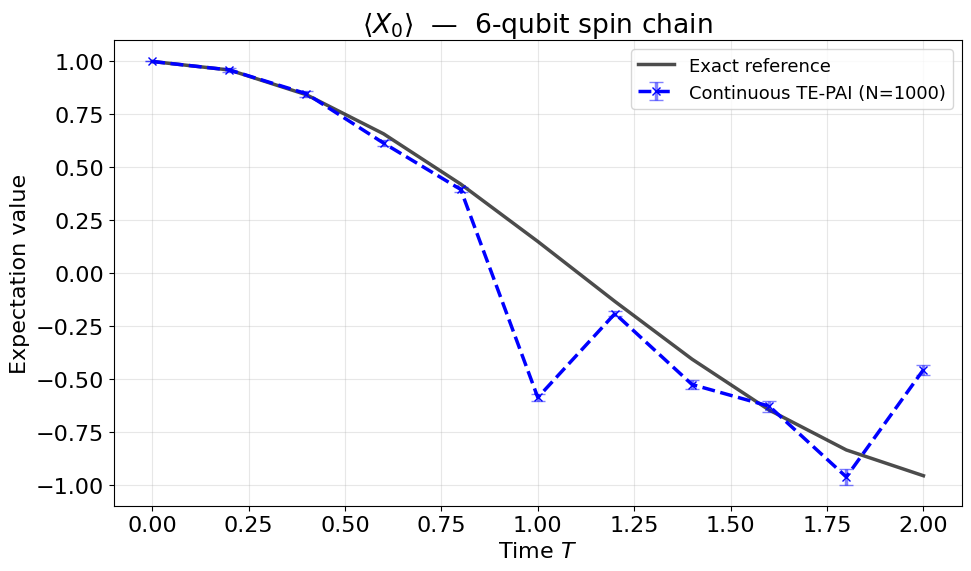

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(snap_times, y_exact, "k-", alpha=0.7, label="Exact reference")
_, caps, bars = plt.errorbar(
    snap_times, y_tepai_mean, yerr=y_tepai_std,
    fmt="b--x", label=f"Continuous TE-PAI (N={num_samples})", capsize=5,
)
for bar in bars: bar.set_alpha(0.5)
for cap in caps: cap.set_alpha(0.5)

plt.title(r"$\langle X_0 \rangle$  —  {}-qubit spin chain".format(num_qubits))
plt.xlabel("Time $T$")
plt.ylabel("Expectation value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
sampler = ContinuousTEPAI(H, delta=delta, total_time=1, seed=42 + i)
sampler.expected_gate_count

np.float64(1193.6734014697788)